# Verification

## Building Blocks

In [44]:
import numpy as np
from numpy.polynomial import Chebyshev, Polynomial, chebyshev
import matplotlib.pyplot as plt
import math

from scipy.linalg import null_space, block_diag
from scipy.optimize import minimize
from scipy.signal import fftconvolve

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_aer.noise import NoiseModel, depolarizing_error

from collections import Counter

In [2]:
verbose = True
np.set_printoptions(precision=5, suppress=True)

### Setting

In [3]:
dim = 4
S = np.arange(dim)

# Basis
eye = np.identity(dim)
basis = np.asarray([row.reshape(-1,1) for row in eye])

# Markov kernel P
P = np.asarray([[1/2, 1/2, 0, 0],
                [1/4, 1/2, 1/4, 0],
                [0, 1/4, 1/2, 1/4],
                [0, 0, 1/2, 1/2]], dtype=float)
if verbose: print(f"Markov kernel: \n{P}")

# Stationary distribution
pi = np.asarray([1/6, 1/3, 1/3, 1/6])

assert np.allclose(P.sum(axis=1), 1.0), "The rows of P don't sum to 1. P is not a Markov Kernel"
assert np.allclose(pi @ P, pi), "pi is not the stationary distribution of P"

if verbose: print(f"\nStationary distribution: \n{pi}")

# State of stationary distribution
pi_state = np.sqrt(pi).reshape(-1, 1)
if verbose: print(f"\nState of stationary distribution:\n{pi_state}")

# Reversibility
for x in range(dim):
    for y in range(dim):
        assert np.allclose(pi[x] * P[x, y], pi[y] * P[y, x]), (f"Detailed balance fails at x={x}, y={y}.")

if verbose: print(f"\nDetailed balance verified.")


Markov kernel: 
[[0.5  0.5  0.   0.  ]
 [0.25 0.5  0.25 0.  ]
 [0.   0.25 0.5  0.25]
 [0.   0.   0.5  0.5 ]]

Stationary distribution: 
[0.16667 0.33333 0.33333 0.16667]

State of stationary distribution:
[[0.40825]
 [0.57735]
 [0.57735]
 [0.40825]]

Detailed balance verified.


### Discriminant
We define the discriminant matrix.

We compute the leading eigenvalue and verify it is 1, since it is a reversible Markov chain.

We compute the spectral gap.

In [4]:
# Discriminant
D = np.zeros((4,4))
for x in range(dim):
    for y in range(dim):
        D[x,y] = np.sqrt(pi[x]/pi[y]) * P[x][y]
if verbose: print(f"Discriminant: \n{D}")

if verbose: 
    if not (np.allclose(D @ D.conj().T, np.identity(D.shape[0])) and np.allclose(D.conj().T @ D, np.identity(D.shape[-1]))):
        print(f"\nD is not unitary.")

# Leading eigenvalue of the discriminant
evals, evecs = np.linalg.eigh(D)

idx = evals.argsort()[::-1]

sorted_evals = evals[idx]
sorted_evecs = evecs[:, idx]
if verbose: print(f"\nSorted eigenvalues: {evals}")

leading_eval, leading_evec = sorted_evals[0], sorted_evecs[:, 0]
if verbose: print(f"\nLeading eigenvalue: {leading_eval}")
if verbose: print(f"\nLeading eigenvector:\n {leading_evec}")

assert np.allclose(leading_eval, 1.0), "Leading value is not 1."

# Spectral gap
second_eval = sorted_evals[1]
spectral_gap = leading_eval - second_eval
print(f"\nSpectral gap: {spectral_gap:.2f}")


Discriminant: 
[[0.5     0.35355 0.      0.     ]
 [0.35355 0.5     0.25    0.     ]
 [0.      0.25    0.5     0.35355]
 [0.      0.      0.35355 0.5    ]]

D is not unitary.

Sorted eigenvalues: [-0.    0.25  0.75  1.  ]

Leading eigenvalue: 1.0

Leading eigenvector:
 [0.40825 0.57735 0.57735 0.40825]

Spectral gap: 0.25


### SPUE
We construct the partial isometry (square):

$\square_P = \sum_{x \in S}\sum_{y \in S}\sqrt{P(x, y)}\ket{x}\ket{y}\bra{x}$

And the swap matrix

$S = \sum_{x, y \in S}\ket{x, y}\bra{x, y}$

We verify (square, S) is a SPUE of the discriminant, i.e:

$\square_P^\dagger S\square_P = D$

In [5]:
# Partial isometry
square = np.zeros((dim * dim, dim))
for x in range(dim):
    for y in range(dim):
        square += np.sqrt(P[x][y]) * np.kron(basis[x], basis[y]) @ basis[x].conj().T #conj().T == dagger

assert np.allclose(square.conj().T @ square, np.identity(square.shape[-1])), "square is not a partial isometry."
if verbose: print(f"Partial isometry:\n{square}")

# Swap
swap = np.zeros((dim * dim, dim * dim))
for x in range(dim):
    for y in range(dim):
        swap += np.kron(basis[x], basis[y]) @ np.kron(basis[y].conj().T, basis[x].conj().T)
if verbose: print(f"\nSwap matrix:\n{swap}")

# SPUE
spue = square.conj().T @ swap @ square

assert np.allclose(D, spue), "(square, swap) is not a SPUE of D"

Partial isometry:
[[0.70711 0.      0.      0.     ]
 [0.70711 0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.5     0.      0.     ]
 [0.      0.70711 0.      0.     ]
 [0.      0.5     0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.5     0.     ]
 [0.      0.      0.70711 0.     ]
 [0.      0.      0.5     0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.70711]
 [0.      0.      0.      0.70711]]

Swap matrix:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

### Reflection and Qubitized Walk Operator

We build the reflection operator R of D.

We build the qubitized walk operator W of D. We verify it is unitary. We need it to be unitary to use GQSP.

$W = (2\square_P\square_P^\dagger - I)S$

In [6]:
# Reflection Operator
projector = square @ square.conj().T
R = 2 * projector - np.identity(square.shape[0]) # (16, 16)

assert np.allclose(projector @ projector, projector), ("square square^dagger is not a projector.")

if verbose: print(f"Reflection operator:\n{R}")

# Qubitized Walk
W = R @ swap # (16, 16)

assert np.allclose(W.conj().T @ W, np.eye(W.shape[-1])), ("W is not unitary.")

if verbose: print(f"Qubitized walk operator:\n{W}")
if verbose: print(f"W is unitary.")

Reflection operator:
[[ 0.       1.       0.       0.       0.       0.       0.       0.
   0.       0.       0.       0.       0.       0.       0.       0.     ]
 [ 1.       0.       0.       0.       0.       0.       0.       0.
   0.       0.       0.       0.       0.       0.       0.       0.     ]
 [ 0.       0.      -1.       0.       0.       0.       0.       0.
   0.       0.       0.       0.       0.       0.       0.       0.     ]
 [ 0.       0.       0.      -1.       0.       0.       0.       0.
   0.       0.       0.       0.       0.       0.       0.       0.     ]
 [ 0.       0.       0.       0.      -0.5      0.70711  0.5      0.
   0.       0.       0.       0.       0.       0.       0.       0.     ]
 [ 0.       0.       0.       0.       0.70711  0.       0.70711  0.
   0.       0.       0.       0.       0.       0.       0.       0.     ]
 [ 0.       0.       0.       0.       0.5      0.70711 -0.5      0.
   0.       0.       0.       0.       0.     

## GQET - Generalized Quantum Eigenvalue Transformation

### Chebyshev Polynomial

We set $\epsilon=0.125$ (we could try different values later to try decreasing the degree of the polynomial).

We calculate the minimum degree d of the Chebyshev polynomial.

In [7]:
# "Allowed error"
epsilon = 0.125

# Degree pf the polynomial
d_raw = np.arccosh(1/epsilon) / np.arccosh(1 / (1 - spectral_gap))
d = int(np.ceil(d_raw))

if verbose: print(f"Degree of the polynomial (float): {d_raw}")
if verbose: print(f"Degree of the polynomial (upper int): {d}")


Degree of the polynomial (float): 3.480990209272064
Degree of the polynomial (upper int): 4


We define the polynomial to select the leading eigenvalue of D.

In [8]:
alpha = np.cosh(np.arccosh(1 / epsilon) / d)
delta_d = 1 - 1 / alpha

assert delta_d <= spectral_gap + 1e-12, ("The chosen degree is not large enough: delta_d > spectral_gap.")

x_poly = Polynomial([0.0, alpha]) # we build alpha * x
nu_power = epsilon * Chebyshev.basis(d)(x_poly) # epsilon * T_d(alpha * x)

# Convert to chebyshex basis
nu = nu_power.convert(kind=Chebyshev)

# Coefficients that nu and the signal polynomial share a1, ...
coef = nu.coef

if verbose: print(f"Coefficients:\n{coef}")


Coefficients:
[0.25804 0.      0.4375  0.      0.30446]


We apply the polynomial directly to D (this cannot happen in a quantum computer since we don't have access to D, D not unitary). 

In [9]:
def cheby_rec(degree, matrix):
    if degree == 0:
        return np.identity(matrix.shape[0])
    elif degree == 1:
        return matrix
    else:
        return 2 * matrix @ cheby_rec(degree - 1, matrix) - cheby_rec(degree - 2, matrix)

In [10]:
assert np.allclose(cheby_rec(0, D), np.identity(D.shape[0])), 'degree 0'
assert np.allclose(cheby_rec(1, D), D), 'degree 1'
assert np.allclose(cheby_rec(2, D), 2 * D @ D - np.identity(D.shape[0])), 'degree 2'
assert np.allclose(cheby_rec(3, D), 4 * D @ D @ D - 3 * D), 'degree 3'
assert np.allclose(cheby_rec(4, D), 8 * D @ D @ D @ D - 8 * D @ D + np.identity(D.shape[0])), 'degree 4'


In [11]:
nu_D = np.zeros_like(D)

for i, a in enumerate(coef):
    nu_D += a * cheby_rec(i, D)

if verbose: print(f"nu(D):\n{nu_D}")

nu(D):
[[0.20575 0.20172 0.25226 0.15223]
 [0.20172 0.38413 0.29486 0.25226]
 [0.25226 0.29486 0.38413 0.20172]
 [0.15223 0.25226 0.20172 0.20575]]


We check that $\nu(D) \approx |\pi><\pi|$

We check that the leading eigenvalue of $\nu(D)$ is close to 1.

We check that the rest of the eigenvalues of $\nu(D)$ are smaller than the allowed error epsilon.

In [12]:
projector_stationary = pi_state @ pi_state.conj().T

filter_error = np.linalg.norm(nu_D - projector_stationary, ord=2)

if verbose:
    print(f"\n|pi><pi|:\n{projector_stationary.real}")
    print(f"nu(D):\n{nu_D}")
    print(f"\n||nu(D) - |pi><pi|||_2 = {filter_error}")

assert filter_error <= epsilon + 1e-10, ("nu(D) is not close enough to the projector onto the stationary distribution.")

if verbose: print("\nnu(D) is close to the projection onto the stationary distribution.")

# Check leading eigenvalue of nu(D) is 1
filtered_evals = chebyshev.chebval(sorted_evals, coef)

if verbose:
    print(f"\nEigenvalues of D:\n{sorted_evals}")
    print(f"\nFiltered eigenvalues nu(lambda):\n{filtered_evals}")

assert np.allclose(filtered_evals[0], 1.0), 'nu(leading_eval) should be 1 by construction.'
if verbose: print(f"\nThe leading eigenvalue of nu(D) is close to 1.")

# Check rest of the eigenvalues
max_filtered_nonleading = np.max(np.abs(filtered_evals[1:]))

assert max_filtered_nonleading <= epsilon + 1e-10, 'At least one of the rest of the eigenvalues is not smaller than epsilon.'
if verbose: print(f"\nThe rest of the eigenvalues of nu(D) are smaller than the allowed error epsilon.")



|pi><pi|:
[[0.16667 0.2357  0.2357  0.16667]
 [0.2357  0.33333 0.33333 0.2357 ]
 [0.2357  0.33333 0.33333 0.2357 ]
 [0.16667 0.2357  0.2357  0.16667]]
nu(D):
[[0.20575 0.20172 0.25226 0.15223]
 [0.20172 0.38413 0.29486 0.25226]
 [0.25226 0.29486 0.38413 0.20172]
 [0.15223 0.25226 0.20172 0.20575]]

||nu(D) - |pi><pi|||_2 = 0.12499999999999999

nu(D) is close to the projection onto the stationary distribution.

Eigenvalues of D:
[ 1.    0.75  0.25 -0.  ]

Filtered eigenvalues nu(lambda):
[1.      0.01779 0.03697 0.125  ]

The leading eigenvalue of nu(D) is close to 1.

The rest of the eigenvalues of nu(D) are smaller than the allowed error epsilon.


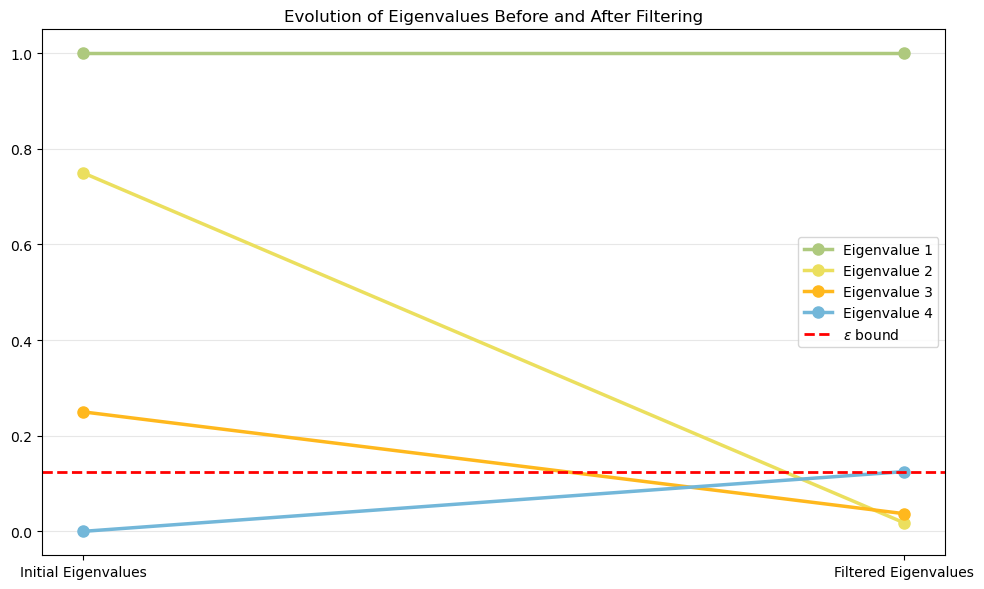

In [13]:
x_labels = ['Initial Eigenvalues', 'Filtered Eigenvalues']

colors = ['#aec97e', '#ebdf5e', '#ffb81d', '#73b7d9'] 

plt.figure(figsize=(10, 6))

for i in range(len(sorted_evals)):
    y_values = [sorted_evals[i], filtered_evals[i]]
    
    plt.plot(x_labels, y_values, marker='o', markersize=8, color=colors[i], 
             linewidth=2.5, label=f'Eigenvalue {i+1}')

plt.axhline(y=epsilon, color='red', linestyle='--', linewidth=2, label='$\epsilon$ bound')

plt.title('Evolution of Eigenvalues Before and After Filtering')
plt.grid(True, axis='y', alpha=0.3)
plt.legend(loc='best')

# Display the plot
plt.tight_layout()
plt.show()

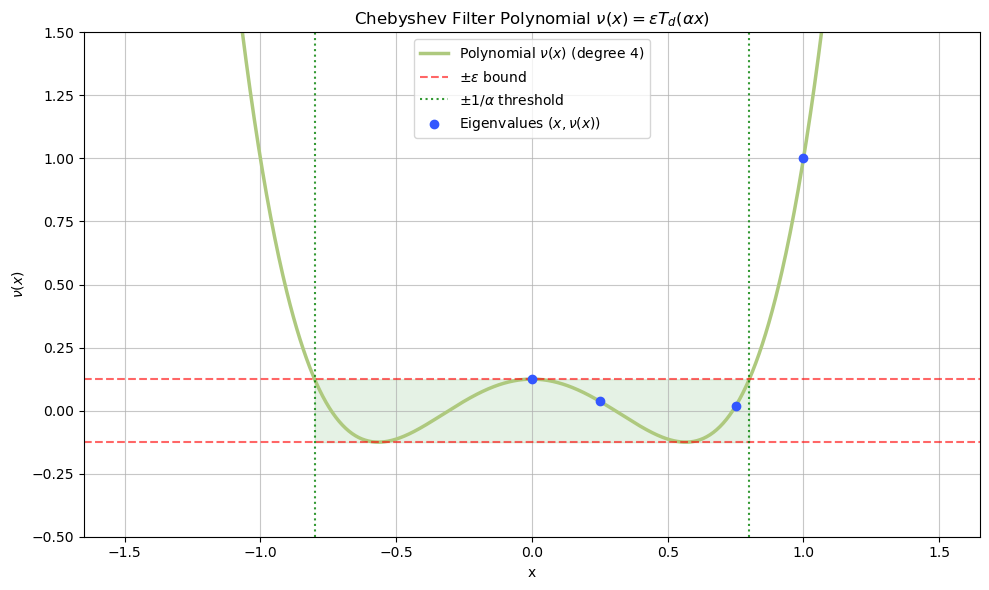

In [14]:
x_vals = np.linspace(-1.5, 1.5, 1000)
y_vals = nu(x_vals)

plt.figure(figsize=(10, 6))

plt.plot(x_vals, y_vals, label=f'Polynomial $\\nu(x)$ (degree {d})', color='#aec97e', linewidth=2.5)

# Epsilon bounds
plt.axhline(epsilon, color='red', linestyle='--', alpha=0.6, label='$\pm\epsilon$ bound')
plt.axhline(-epsilon, color='red', linestyle='--', alpha=0.6)

# Region that has to be less than epsilon
bound_x = 1 / alpha
plt.axvline(bound_x, color='green', linestyle=':', alpha=0.8, label='$\pm 1/\\alpha$ threshold')
plt.axvline(-bound_x, color='green', linestyle=':', alpha=0.8)

plt.fill_between(x_vals, -epsilon, epsilon, 
                 where=(np.abs(x_vals) <= bound_x), 
                 color='green', alpha=0.1)

# Plot eigenvalues
y_evals = nu(sorted_evals)
plt.scatter(sorted_evals, y_evals, color='#3357FF', zorder=5, label='Eigenvalues $(x, \\nu(x))$')

plt.title('Chebyshev Filter Polynomial $\\nu(x) = \epsilon T_d(\\alpha x)$')
plt.xlabel('x')
plt.ylabel('$\\nu(x)$')
plt.ylim(-0.5, 1.5)
plt.grid(True, alpha=0.7)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

### GQSP - Generalized Quantum Signal Processing

We start simply verifying that $\square^\dagger_P \Upsilon(W) \square_P = \nu(D)$

In [15]:
# Signal processing polynomial
upsilon_W = np.zeros_like(W)
power = np.identity(W.shape[0])

for c in coef:
    upsilon_W += c * power
    power = power @ W

nu_D_walk = square.conj().T @ upsilon_W @ square

assert np.allclose(nu_D_walk, nu_D), 'nu(D) through W is NOT the same as applying nu(D)'
if verbose: print("nu(D) through W is the same as applying nu(D).")
if verbose: print(f"\nnu_D through W:\n{nu_D_walk}")

nu(D) through W is the same as applying nu(D).

nu_D through W:
[[0.20575 0.20172 0.25226 0.15223]
 [0.20172 0.38413 0.29486 0.25226]
 [0.25226 0.29486 0.38413 0.20172]
 [0.15223 0.25226 0.20172 0.20575]]


# Quantum Circuit

Ordering problem. Qiskit uses little-endian: the LSB is saved at position 0.

## Registries
We build a circuit with the following quantum registries:
- x: 2 qubits (state register)
- y: 2 qubits (transition register)
- s: 1 qubit (GQSP)

and classical registries:
- cx: 2 bits
- y: 2 bits
- s: 1 bit

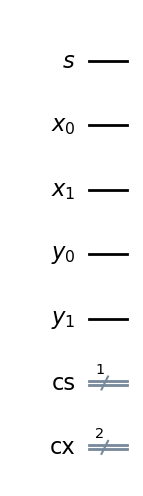

In [16]:
# Quantum registers
qs = QuantumRegister(1, "s")
qx = QuantumRegister(2, "x")
qy = QuantumRegister(2, "y")

# Classical registers
cs = ClassicalRegister(1, "cs")
cx = ClassicalRegister(2, "cx")

# Quantum circuit
qc = QuantumCircuit(qs, qx, qy, cs, cx)

qc.draw("mpl")

We initialize:
- $\text{s} \to \ket{0}$
- $\text{x} \to \frac{1}{\sqrt{N}}\sum_{x \in S}\ket{x}$
- $\text{y} \to \ket{00}$

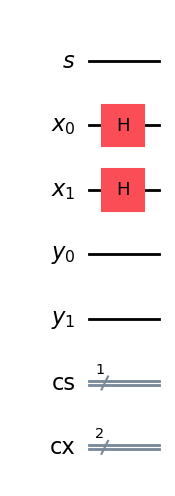

In [17]:
qc.h(qx[0])
qc.h(qx[1])

qc.draw('mpl')

**==>** State of the circuit: $\ket{0}\ket{u}\ket{00} = 0.5 \sum_{x \in S}\ket{0}\ket{x}\ket{00}$ 

## Partial Isometry 
In order to apply the partial isometry in a circuit, we need it to be unitary.

We build V = sum_{x}{|x><x| tensor V_x!>}.

V_x is built to be a unitary with the first column equal to |psi_x>

V_x|0> = |psi_x>

In [18]:
# Function to build V_x such that it is unitary and its first column is |psi_x>
def complete_vector_to_unitary(v, atol=1e-12):
    """
    Given a normalized vector v in C^n, build a unitary U
    whose first column is v.
    """
    v = np.asarray(v, dtype=complex).reshape(-1, 1)
    n = v.shape[0]

    norm = np.linalg.norm(v)
    assert np.allclose(norm, 1.0, atol=atol), f"Input vector is not normalized. Norm = {norm}"

    # Find an orthonormal basis of the orthogonal complement of v.
    # This returns an n x (n-1) matrix Q such that v^dagger Q = 0.
    complement = null_space(v.conj().T)

    U = np.hstack([v, complement])

    assert np.allclose(U.conj().T @ U, np.eye(n), atol=atol), "Completion failed: U is not unitary."

    assert np.allclose(U[:, 0], v[:, 0], atol=atol), "First column is not the requested vector."

    return U


# Function to build V, controlled V_x
def build_controlled_unitary_extension(P, atol=1e-12):
    """
    Build V = sum_x |x><x| tensor V_x,
    where V_x |0> = sum_y sqrt(P[x,y]) |y>.
    """
    P = np.asarray(P, dtype=float)
    dim = P.shape[0]

    assert P.shape == (dim, dim), "P must be square."

    assert np.allclose(P.sum(axis=1), 1.0, atol=atol), "Rows of P must sum to 1."

    blocks = []

    for x in range(dim):
        psi_x = np.sqrt(P[x, :]).astype(complex)
        V_x = complete_vector_to_unitary(psi_x, atol=atol)
        blocks.append(V_x)

    V = block_diag(*blocks)

    assert np.allclose(V.conj().T @ V, np.eye(dim * dim), atol=atol), "V is not unitary."

    return V, blocks

In [19]:
V, V_blocks = build_controlled_unitary_extension(P)

if verbose: 
    print(f"Shape of V: {V.shape}")
    print(f"\nUnitary extension of square:\n{V}")
    for i, V_x in enumerate(V_blocks):
        print(f"\nBlock V_{i}:\n{V_x}")


Shape of V: (16, 16)

Unitary extension of square:
[[ 0.70711+0.j -0.70711-0.j  0.     -0.j  0.     -0.j  0.     +0.j
   0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j
   0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j
   0.     +0.j]
 [ 0.70711+0.j  0.70711-0.j  0.     -0.j  0.     -0.j  0.     +0.j
   0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j
   0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j
   0.     +0.j]
 [ 0.     +0.j  0.     -0.j  1.     -0.j  0.     -0.j  0.     +0.j
   0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j
   0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j
   0.     +0.j]
 [ 0.     +0.j  0.     -0.j  0.     -0.j  1.     -0.j  0.     +0.j
   0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j
   0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j
   0.     +0.j]
 [ 0.     +0.j  0.     +0.j  0.     +0.j  0.     +0.j  0.5    +0.j
  -0.70711-0.j

In [20]:
for x in range(dim):
    input_col = dim * x + 0
    assert np.allclose(V[:, input_col], square[:, x])

print("V correctly extends square.")

V correctly extends square.


This is how the paper actually computes the walk operator.

In [21]:
rot = 2 * basis[0] @ basis[0].conj().T - np.identity(dim)
W_new = V @ np.kron(np.identity(dim), rot) @ V.conj().T @ swap

assert np.allclose(W, W_new)

Since our ordering is big-endian and the one used by Qiskit is little-endian we neet to apply a permutation to build the correct gate for V.

In [22]:
def math_to_qiskit_permutation(dim=4):
    """
    Mathematical ordering:
        |x,y> -> dim*x + y

    Qiskit ordering for qubits [x[0], x[1], y[0], y[1]]:
        |x,y> -> x + dim*y
    """
    N = dim * dim
    Perm = np.zeros((N, N), dtype=complex)

    for x_state in range(dim):
        for y_state in range(dim):
            math_index = dim * x_state + y_state
            qiskit_index = x_state + dim * y_state
            Perm[qiskit_index, math_index] = 1.0

    return Perm

In [23]:
perm = math_to_qiskit_permutation(dim)
if verbose: print(f"Permutation to go from big-endian to little-endian:\n{perm.real}")
V_qiskit = perm @ V @ perm.conj().T

assert np.allclose(V_qiskit.conj().T @ V_qiskit, np.eye(16)), "V is not unitary."
if verbose: print(f"\nV with little-endian ordering:\n{V_qiskit}")

Permutation to go from big-endian to little-endian:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]

V with little-endian ordering:
[[ 0.70711+0.j  0.     +0.j  0.     +0.j  0.     +0.j -0.70711+0.j
   0.     +0.j  0.     +0.j  0. 

We apply the gate of V to the registry x and y.

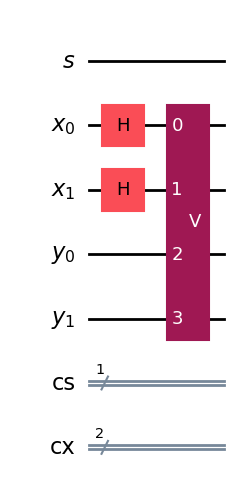

In [ ]:
V_gate = UnitaryGate(V_qiskit, label="V")
qc.append(V_gate, list(qx) + list(qy))

qc.draw("mpl")

**==>** State of the circuit: 0.5 * sum_x{|0> |x> |psi_x>}

## Finding the rotation angles for GQSP

The next gate to implement is the one which applies the polynomial $\Upsilon(W)$. To do it, we must find a polynomial $Q$ (ref GQSP paper) and compute the rotations angle that are discussed in the GQSP paper. It is therefore good practice to define a $2$ functions, one that given the polynomial $\Upsilon$ outputs the polynomial $Q$ and the other that given a polynomial in the standard basis, returns the angles. 

In [25]:
# Function simply implement the algorithm explained in the paper of GQSP
def find_Q_polynomial(P_coefs):
    """
    Calculates the coefficients of polynomial Q given polynomial P 
    for Generalized Quantum Signal Processing (GQSP).
    
    Args:
        P_coefs (numpy.ndarray): Complex coefficients of P [a_0, a_1, ..., a_d]
        
    Returns:
        numpy.ndarray: Complex coefficients of Q [b_0, b_1, ..., b_d]
    """
    a = np.array(P_coefs, dtype=complex)
    d = len(a) - 1
    
    a_rev_conj = np.conjugate(a[::-1])
    a_conv = fftconvolve(a, a_rev_conj)
    
    delta = np.zeros(2*d + 1, dtype=complex)
    delta[d] = 1.0
    
    target_b_conv = delta - a_conv
    
    def objective(b_concat):

        b = b_concat[:d+1] + 1j * b_concat[d+1:]
        
        # Compute b * reverse(b)*
        b_rev_conj = np.conjugate(b[::-1])
        b_conv = fftconvolve(b, b_rev_conj)
        
        # L2 norm squared of the difference
        diff = b_conv - target_b_conv
        return np.sum(np.abs(diff)**2)

    np.random.seed(42) # Fixed seed for reproducibility 
    b_init = np.random.randn(d+1) + 1j * np.random.randn(d+1)
    
    x0 = np.concatenate([np.real(b_init), np.imag(b_init)])
    
    result = minimize(objective, x0, method='L-BFGS-B', 
                      options={'maxiter': 50000, 'ftol': 1e-12})
    
    if not result.success:
        print(f"Warning: Optimization may not have fully converged. Message: {result.message}")
        print(f"Final objective value: {result.fun}")
        
    b_opt = result.x[:d+1] + 1j * result.x[d+1:]
    
    return b_opt

P_coefficients = np.array(coef)

Q_coefficients = find_Q_polynomial(P_coefficients)

if verbose:
    print("Coefficients of P:")
    print(np.round(P_coefficients, 4))
    print("\nFound Coefficients for Q:")
    print(np.round(Q_coefficients, 4))

Coefficients of P:
[0.258  0.     0.4375 0.     0.3045]

Found Coefficients for Q:
[ 0.2542+0.1154j -0.2036+0.4503j -0.0025+0.0002j  0.2064-0.4532j
 -0.2562-0.1163j]


In [26]:
# This function computes the rotation angles given P and Q according to the algorithm given in the GQSP paper.
def compute_rotation_angles(S, d):
    """
    Computes the rotation angles for GQSP.
    
    Args:
        S (numpy.ndarray): 2 x (d+1) complex matrix where the first row 
                           contains the coefficients of P and the second row 
                           contains the coefficients of Q.
        d (int): Degree of the polynomials.
        
    Returns:
        tuple: (theta_list, phi_list, lambda_val)
               where theta_list and phi_list are ordered from index 0 to d.
    """
    theta_list = []
    phi_list = []
    
    # Make a copy to avoid mutating the original input
    current_S = np.array(S, dtype=complex)
    
    # Process from degree d down to 1
    for current_d in range(d, 0, -1):
        a_d = current_S[0][current_d]
        b_d = current_S[1][current_d]
        
        abs_a = np.abs(a_d)
        abs_b = np.abs(b_d)
        
        theta_d = np.arctan2(abs_b, abs_a)
        if abs_b == 0:
            phi_d = np.angle(a_d)
        elif abs_a == 0:
            phi_d = -np.angle(b_d)
        else:
            phi_d = np.angle(a_d * np.conj(b_d))
            
        theta_list.append(theta_d)
        phi_list.append(phi_d)
        
        exp_neg_i_phi = np.exp(-1j * phi_d)
        cos_t = np.cos(theta_d)
        sin_t = np.sin(theta_d)
        
        R_dagger = np.array([
            [exp_neg_i_phi * cos_t,  sin_t],
            [exp_neg_i_phi * sin_t, -cos_t]
        ])
        
        S_temp = R_dagger @ current_S
        
        P_hat = S_temp[0][1:]  
        
        Q_hat = S_temp[1][:-1] 
        
        current_S = np.array([P_hat, Q_hat])
        
    a_0 = current_S[0][0]
    b_0 = current_S[1][0]
    
    abs_a0 = np.abs(a_0)
    abs_b0 = np.abs(b_0)
    
    theta_0 = np.arctan2(abs_b0, abs_a0)
    
    if abs_b0 == 0:
        phi_0 = np.angle(a_0)
        lambda_val = 0.0
    elif abs_a0 == 0:
        phi_0 = -np.angle(b_0)
        lambda_val = np.angle(b_0)
    else:
        phi_0 = np.angle(a_0 * np.conj(b_0))
        lambda_val = np.angle(b_0)
        
    theta_list.append(theta_0)
    phi_list.append(phi_0)
    
    # Reverse the lists because we processed from d down to 0, 
    # but the circuit requires them from 0 up to d.
    theta_list.reverse()
    phi_list.reverse()
    
    return theta_list, phi_list, lambda_val

We compute the rotation angles

In [27]:
# Build S first

S = np.vstack([P_coefficients, Q_coefficients])

# Computing the angles

theta_list, phi_list, lambda_val = compute_rotation_angles(S, d)

if verbose:
    print(f"Theta list: {theta_list}")
    print(f"Phi list: {phi_list}")
    print(f"lambda_val: {lambda_val}")

Theta list: [np.float64(0.7421365375656978), np.float64(0.7225906010558145), np.float64(0.003883313351271157), np.float64(0.7229092672503551), np.float64(0.7460096424917101)]
Phi list: [np.float64(-1.572112848606204), np.float64(-1.5930629405866346), np.float64(-1.5459133145175012), np.float64(1.5694874596723283), np.float64(2.7155730913535514)]
lambda_val: 0.4260285526844599


## Finding the gate which applies the polynomial

It is now time to find the gate that applies the polynomial $\Upsilon(W)$. But first we need to define the gates $R(\theta, \psi, \lambda) = \begin{pmatrix}e^{i(\lambda + \psi)}\cos(\theta) & e^{i\psi}\sin(\theta) \\ e^{i\lambda}\sin(\theta) & -\cos(\theta)\end{pmatrix} \otimes I$ and $A = (\ket{0}\bra{0} \otimes W) + (\ket{1}\bra{1} \otimes I)$

In [28]:
# Defining the rotation gate, since it has parameters it needs to be 
# defined as a subclass of the Gate class


def RotationGate(theta, phi, lam):
    """
    Computes the GQSP rotation matrix and returns it as a Qiskit UnitaryGate 
    """
    U = np.array([
        [
            np.exp(1j * (lam + phi)) * np.cos(theta),
            np.exp(1j * phi) * np.sin(theta)
        ],
        [
            np.exp(1j * lam) * np.sin(theta),
            -np.cos(theta)
        ]
    ], dtype=complex)
    
    # Wrap and return the matrix as a UnitaryGate
    return UnitaryGate(U, label=r"$R_{GQSP}$")

# Permuting W gate
# W_qiskit = perm @ W @ perm.conj().T
W_qiskit = perm @ W_new @ perm.conj().T

assert np.allclose(W_qiskit.conj().T @ W_qiskit, np.eye(16)), "W_qiskit not unitary"
        
# Defining the A gate
# W_gate = UnitaryGate(W_qiskit, label="W")
W_gate = UnitaryGate(W_qiskit, label="W")

A = W_gate.control(num_ctrl_qubits=1, ctrl_state="0")

Let's create the gate

Theta list: [np.float64(0.7421365375656978), np.float64(0.7225906010558145), np.float64(0.003883313351271157), np.float64(0.7229092672503551), np.float64(0.7460096424917101)]
Phi list : [np.float64(-1.572112848606204), np.float64(-1.5930629405866346), np.float64(-1.5459133145175012), np.float64(1.5694874596723283), np.float64(2.7155730913535514)]
Lambda: 0.4260285526844599


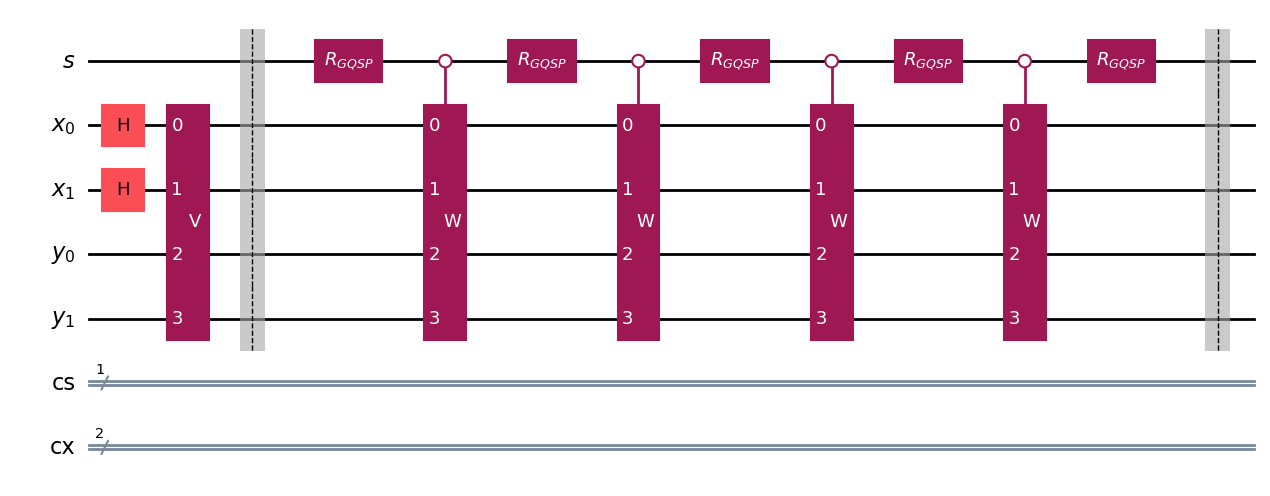

In [ ]:
#Iterating over reversed list so that we start from the
#Lower indexed angles in the order according to GQSP
qc.barrier()
for index, angle_theta in enumerate(theta_list):

    angle_phi = phi_list[index]

    if index == 0:
        R_gate = RotationGate(angle_theta, angle_phi, lambda_val)
    else:
        R_gate = RotationGate(angle_theta, angle_phi, 0)
        qc.append(A, list(qs) + list(qx) + list(qy))

    qc.append(R_gate, qs)

if verbose:
    print(f"Theta list: {theta_list}")
    print(f"Phi list : {phi_list}")
    print(f"Lambda: {lambda_val}")

qc.barrier()

qc.draw("mpl")

## Finishing the circuit

Last part of the circuit is to apply $\square^\dagger_P$ to the $x$ and $y$ registries. Remember that the goal was to implement $(\bra{0} \otimes \square^\dagger_P) G (\ket{0} \otimes \square_P)$.

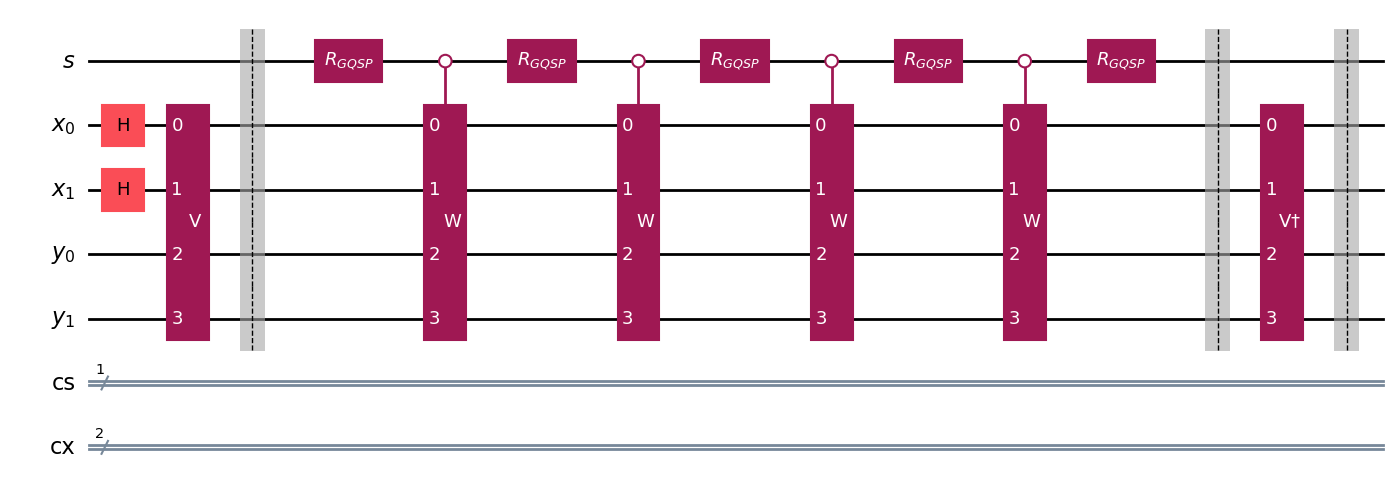

In [30]:
# Creating square dagger
V_gate_dagger = UnitaryGate(V_qiskit.conj().T, label=r"V$\dagger$")

qc.append(V_gate_dagger, list(qx) + list(qy))
qc.barrier()

qc.draw("mpl")

## Measurements

We get to final part of the circtuit, where we measure the output. A measurement of the ancillary qubit and of the $x$ registry is made.

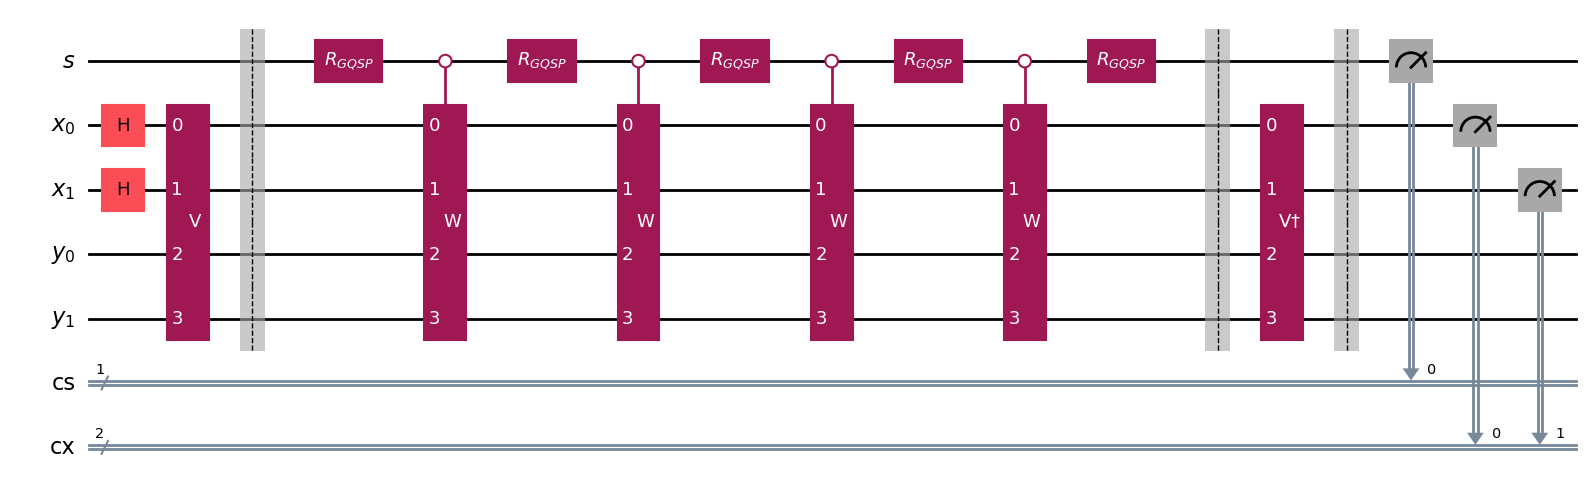

In [31]:
# Measuring the ancillary qubits and the x register
qc.measure(qs, cs)

qc.measure(qx, cx)

qc.draw("mpl")

## Running the simulation

Original circuit depth: 13
Compiled circuit depth: 1824
Gate counts: OrderedDict([('u', 982), ('cx', 926), ('rz', 466), ('u2', 80), ('unitary', 5), ('u3', 5), ('barrier', 3), ('measure', 3), ('h', 2)])
Raw counts: {'10 1': 92, '00 1': 44, '11 0': 1681, '10 0': 3251, '11 1': 70, '01 1': 75, '00 0': 1620, '01 0': 3167}


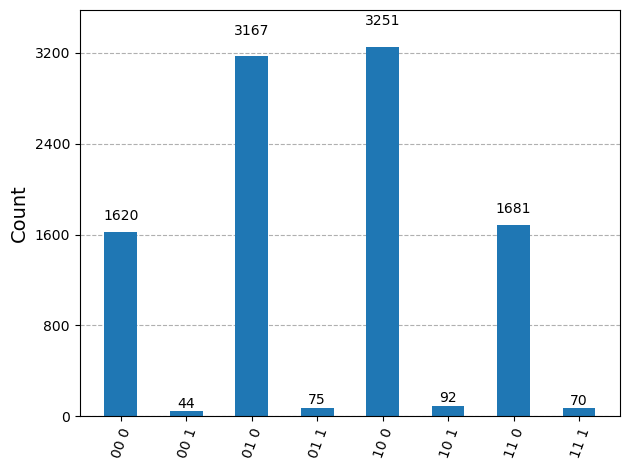

In [32]:
simulator_noiseless = AerSimulator() # Creating a virtual quantum computer

transpiled_qc = transpile(qc, simulator_noiseless) # Compiling the quantum circuit
if verbose:
    print("Original circuit depth:", qc.depth())
    print("Compiled circuit depth:", transpiled_qc.depth())
    print("Gate counts:", transpiled_qc.count_ops())

# Running the circuit 10 000 times
trials = 10000
job = simulator_noiseless.run(transpiled_qc, shots=trials) # Running the simulation

results = job.result() # Obtaining the results from the simulation

raw_counts = results.get_counts()
if verbose: print(f"Raw counts: {raw_counts}")
plot_histogram(raw_counts)

## Checking the results

The final metrics is the total variation distance between the original MC distribution and the distribution given by the quantum computer. Rememeber that the total variation distance is given by: $\|\mu - \nu\|_{TV} = \frac{1}{2}\sum_{i \in S}\left|{\mu_i - \nu_i}\right|$

In [33]:
# We select only the counts that have ancillary qubit equal to 0
post_selected_counts = {}
successes = 0

for bit_string, count in raw_counts.items():

    cx_val, cs_val = bit_string.split()

    if cs_val == '0':
        post_selected_counts[cx_val] = post_selected_counts.get(cx_val, 0) + count
        successes += count

if verbose:
    print(f"Post selected counts: {post_selected_counts}")
    print(f"GQSP success rate: {successes/trials * 100}%")

#Printing the resulting probability distribution and measuring it's distance from the original one

probabilities = {}

for bit_string, count in post_selected_counts.items():

    probabilities[bit_string] = count / successes

if verbose: print(f"Final probability distribution: {probabilities}")

var_distance = 0

for i in range(len(pi)):
    
    cx_bitstring = f"{i:02b}"  # converting the digit to 2 bit binary so it's comparable with the dictionary
    
    # It could happen that the state never got measured if it has a very low probability
    measured_prob = probabilities.get(cx_bitstring, 0.0)
    
    original_value = pi[i]
    var_distance += np.abs(original_value - measured_prob)

var_distance = 0.5 * var_distance

if verbose:
    print(f"Total variation distance between the original and the obtained probability distribution: {var_distance}")
    if var_distance < 0.05:
        print("Quantum computer is sampling with very high precision!")


Post selected counts: {'11': 1681, '10': 3251, '00': 1620, '01': 3167}
GQSP success rate: 97.19%
Final probability distribution: {'11': 0.17296018108858935, '10': 0.33449943409815824, '00': 0.16668381520732586, '01': 0.3258565696059265}
Total variation distance between the original and the obtained probability distribution: 0.007476763727406813
Quantum computer is sampling with very high precision!


## A Reality Check

### Fake Backend with Noise

We run the circuit on a simulator with noise. The circuit is evidently not robust to errors: we obtain a uniform distribution.

Noisy counts: {'01 1': 1175, '11 1': 1067, '00 0': 1382, '01 0': 1474, '10 1': 1158, '10 0': 1391, '11 0': 1271, '00 1': 1082}


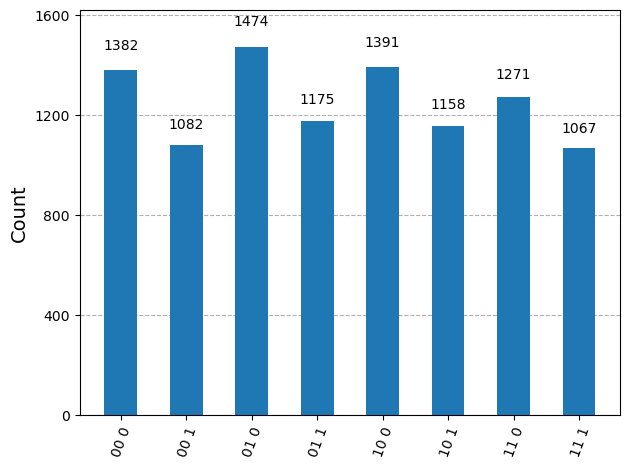

In [34]:
fake_backend = GenericBackendV2(num_qubits=5)
simulator_noise = AerSimulator.from_backend(fake_backend)

compiled_qc = transpile(qc, simulator_noise) 

trials = 10000
job = simulator_noise.run(compiled_qc, shots=trials) 
results = job.result() 

raw_counts = results.get_counts()
if verbose: print(f"Noisy counts: {raw_counts}")
plot_histogram(raw_counts)

### Real Quantum Computer

In [35]:
QiskitRuntimeService.save_account(
  token="I5zSKvHlFxB9Kw5qYwq5m039_MsU1Kjh2UZvX-4LS_iU",
  set_as_default=True,
  overwrite=True
)

qiskit_runtime_service.__init__:WARNING:2026-05-16 20:04:49,127: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-16 20:04:50,026: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-16 20:04:53,222: Using instance: open-instance, plan: open


Selected real backend: ibm_fez
Job ID: d84b3hugbeec73anth90
Combined counts: {'1 01': 1034, '0 10': 1490, '0 01': 1299, '0 00': 1335, '1 11': 1152, '0 11': 1586, '1 10': 1149, '1 00': 955}


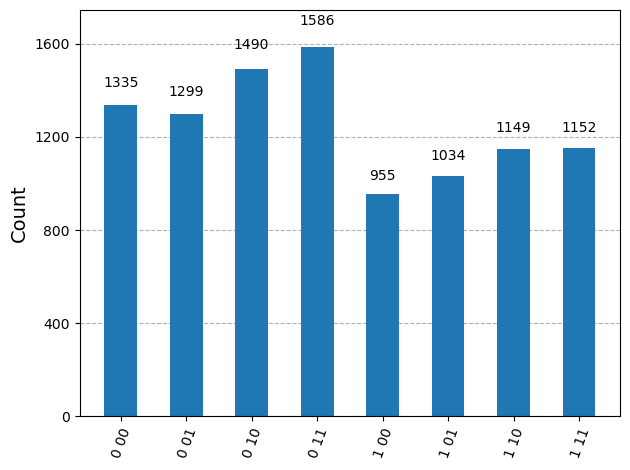

In [36]:
# Load saved account
service = QiskitRuntimeService()

# Find the least busy real quantum computer
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
print(f"Selected real backend: {backend.name}")

# Transpile the circuit for this specific hardware
compiled_qc = transpile(qc, backend=backend, optimization_level=3)

# Set up the Sampler primitive
sampler = Sampler(backend)

# Submit the job
trials = 10000
job = sampler.run([compiled_qc], shots=trials) 

if verbose:
  print(f"Job ID: {job.job_id()}")

result = job.result()
pub_result = result[0]

cs_shots = pub_result.data.cs.get_bitstrings()
cx_shots = pub_result.data.cx.get_bitstrings()
combined_shots = [f"{cs} {cx}" for cs, cx in zip(cs_shots, cx_shots)]
joint_counts = dict(Counter(combined_shots))

if verbose: print(f"Combined counts: {joint_counts}")
plot_histogram(joint_counts)

In [37]:
# noise evaluation 
# total variational distance (classic and quantum)
# ising model

### Controlled Noise

We select a simple but still representative type of error: depolarizing error on 1-qubit and 2-qubit gates. We vary the probability of error, p, and analyze the total variational distance of the obtained distribution and the desired one. 

In [ ]:
def create_noise_model(p):
    noise_model = NoiseModel()

    error_1q = depolarizing_error(p / 10, 1)
    error_2q = depolarizing_error(p, 2)

    one_qubit_gates = ["x", "sx", "rz"]
    two_qubit_gates = ["cx"]

    noise_model.add_all_qubit_quantum_error(error_1q, one_qubit_gates)
    noise_model.add_all_qubit_quantum_error(error_2q, two_qubit_gates)

    return noise_model

def compute_vd(counts, pi):
    post_selected_counts = {}
    successes = 0

    for bit_string, count in counts.items():
        cx_val, cs_val = bit_string.split()

        if cs_val == '0':
            post_selected_counts[cx_val] = post_selected_counts.get(cx_val, 0) + count
            successes += count
    
    # Compute obtained probability distribution
    probabilities = {}
    for bit_string, count in post_selected_counts.items():

        probabilities[bit_string] = count / successes
    
    # Compute variational distance
    var_distance = 0
    for i in range(len(pi)):
        cx_bitstring = f"{i:02b}"
        measured_prob = probabilities.get(cx_bitstring, 0.0)
        
        original_value = pi[i]
        var_distance += np.abs(original_value - measured_prob)

    var_distance = 0.5 * var_distance
    return probabilities, var_distance, post_selected_counts    

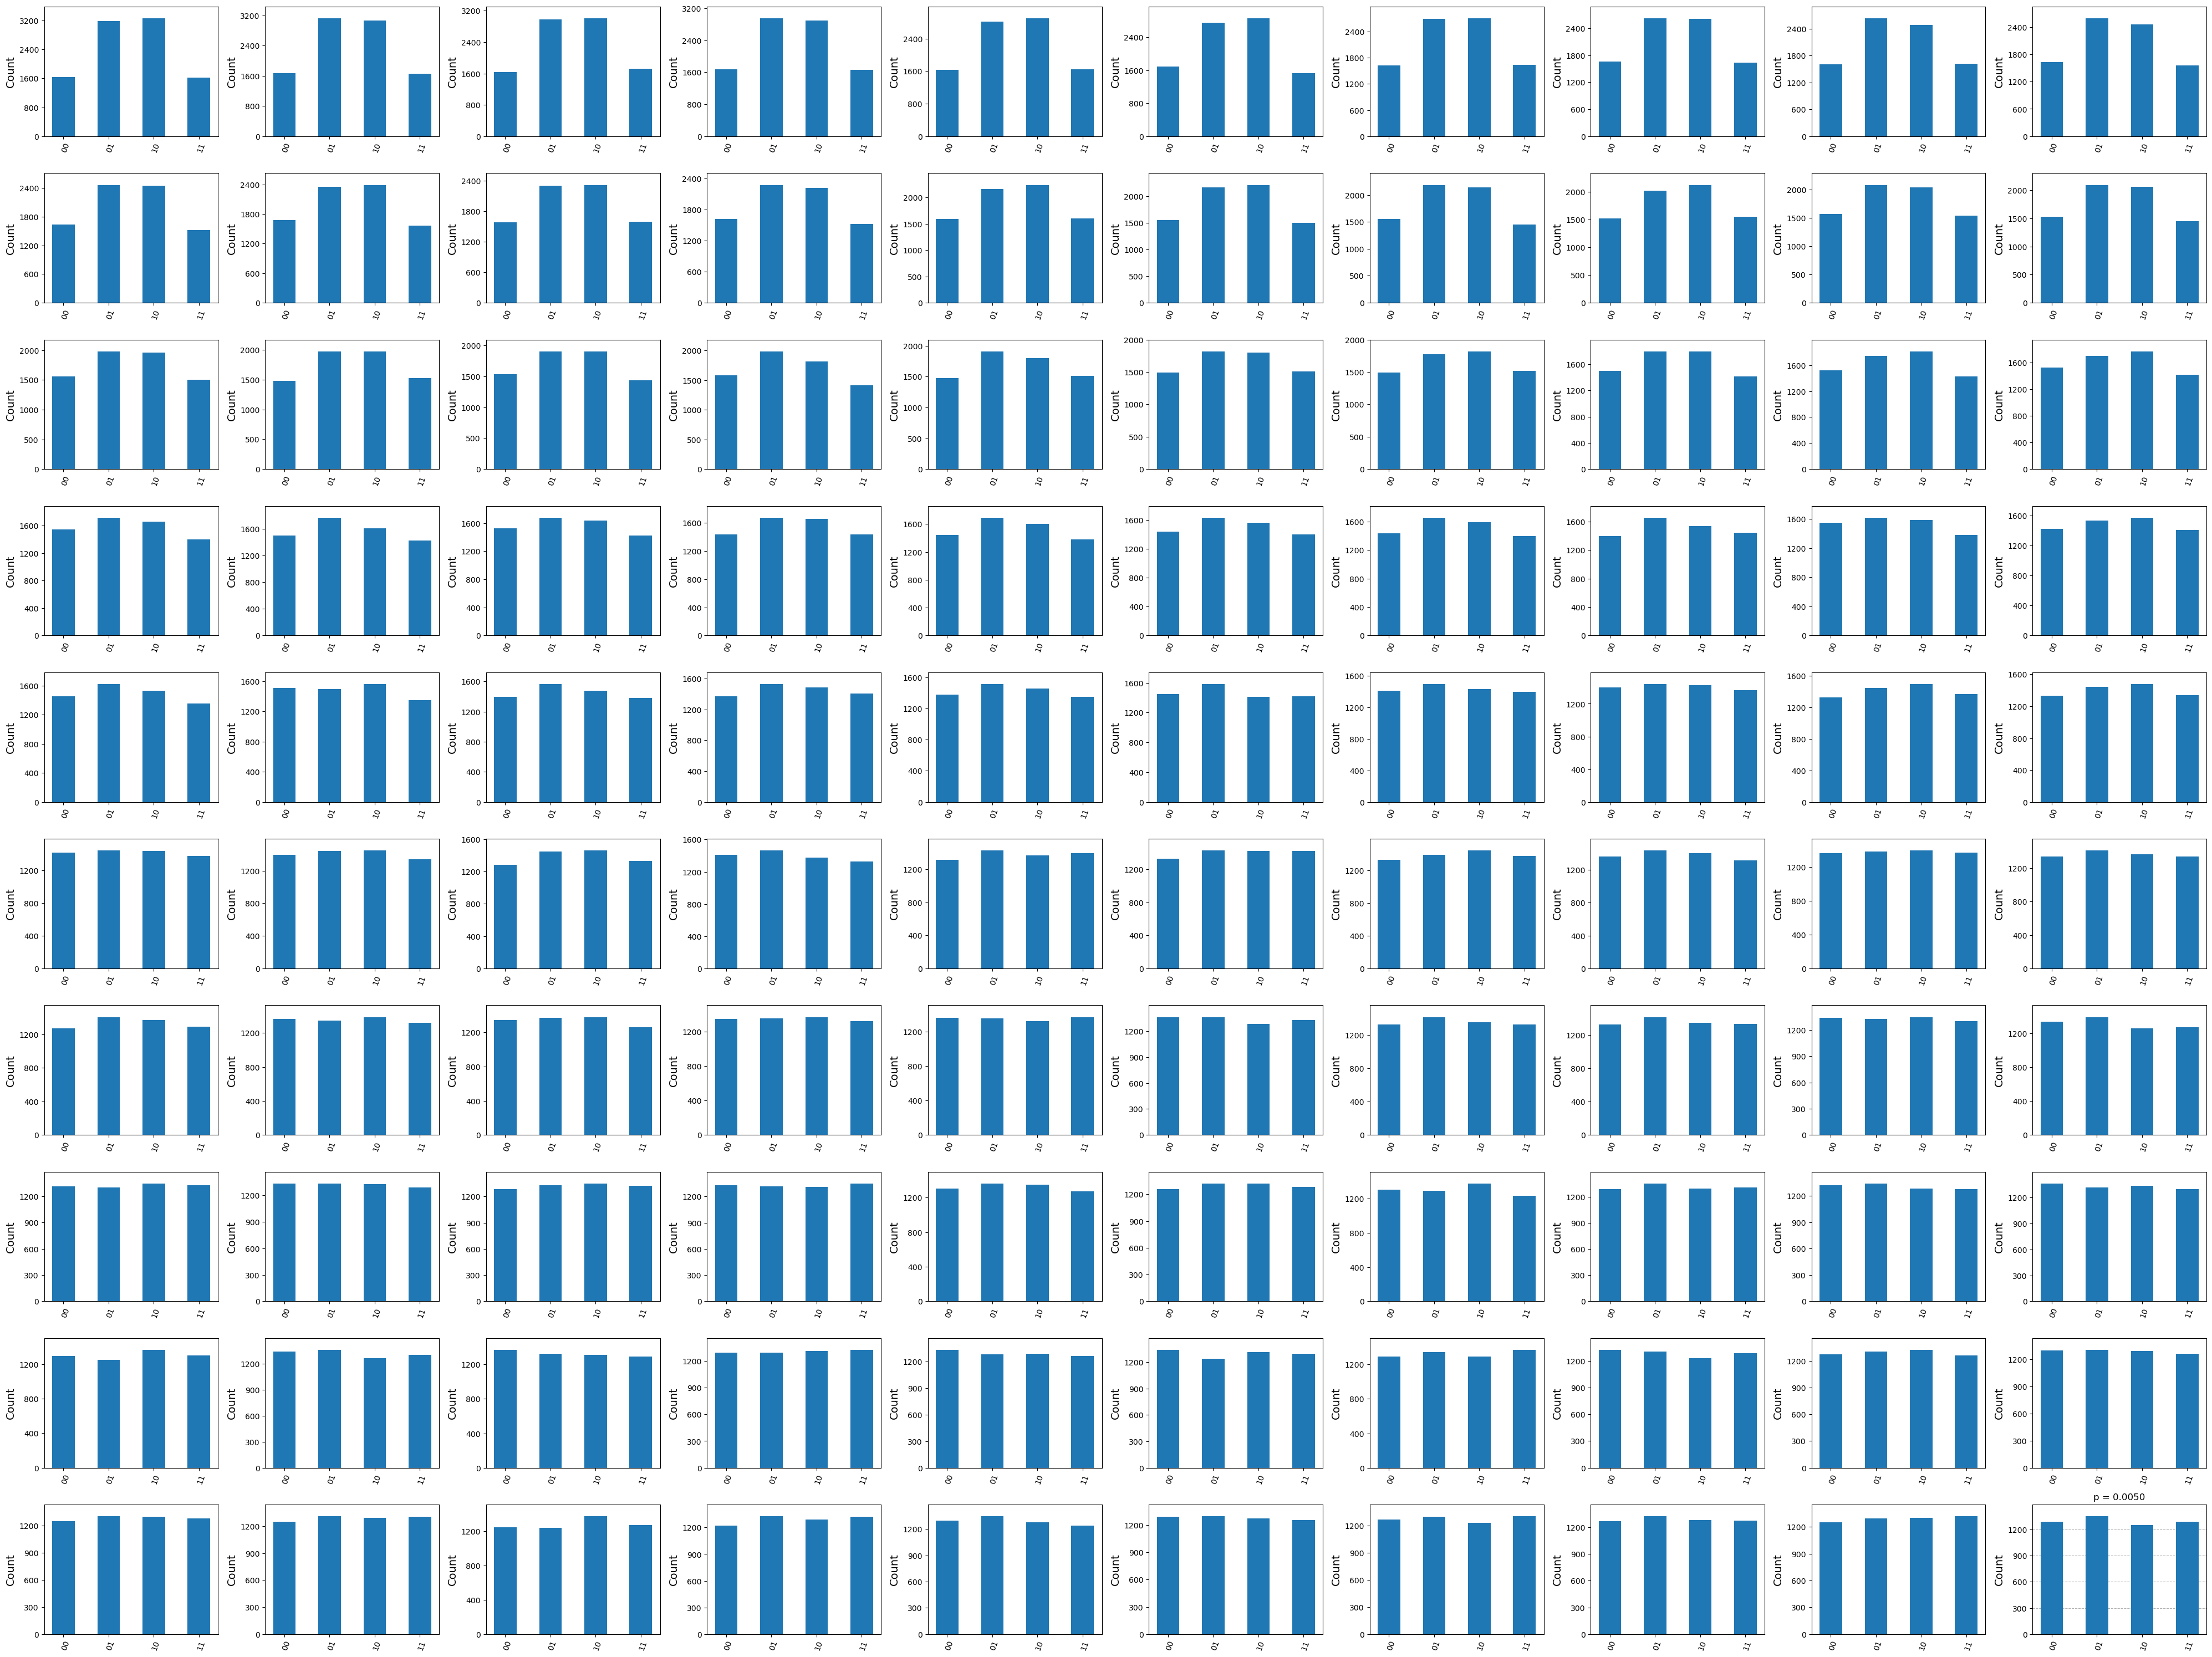

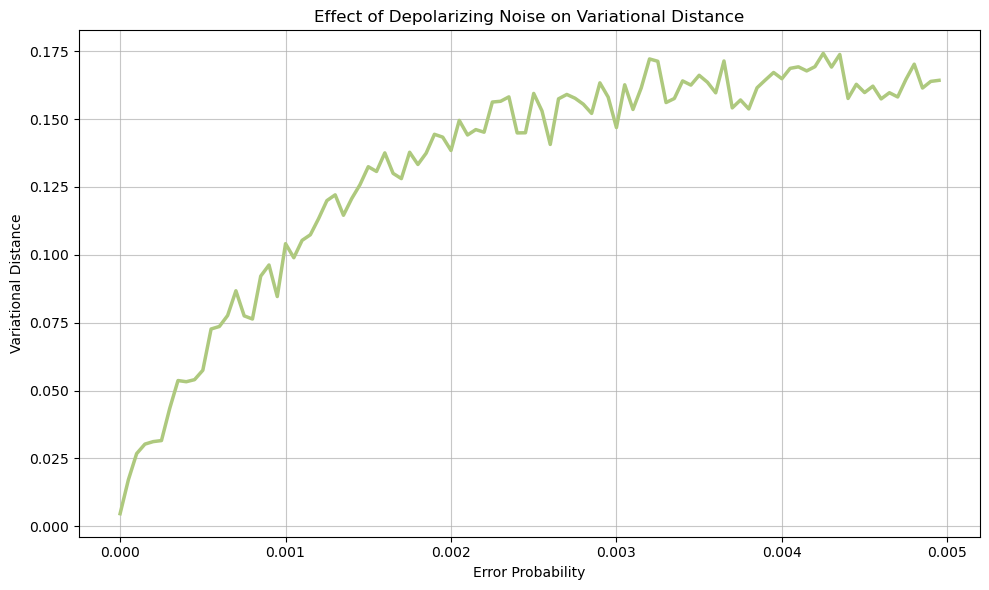

In [ ]:
p_vals = np.arange(0, 5e-3, 5e-5)
vd_vals = []
all_counts = []

for p in p_vals:
    noise_model = create_noise_model(p)

    simulator_dep = AerSimulator(noise_model=noise_model)
    qc_transpiled = transpile(qc, simulator_dep)
    results_dep = simulator_dep.run(qc_transpiled, shots=trials).result()
    raw_counts_dep = results_dep.get_counts()

    probs, vd, counts_dep = compute_vd(raw_counts_dep, pi)

    vd_vals.append(vd)
    all_counts.append(counts_dep)

# Plot histograms
n_plots = len(p_vals)
n_cols = 10
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows)
)

axes = axes.flatten()
for i, (p, counts_dep) in enumerate(zip(p_vals, all_counts)):
    plot_histogram(
        counts_dep,
        ax=axes[i],
        title=f"p = {p:.4f}",
        bar_labels=False
    )

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
    
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(p_vals, vd_vals, color='#aec97e', linewidth=2.5)

plt.title('Effect of Depolarizing Noise on Variational Distance')
plt.xlabel('Error Probability')
plt.ylabel('Variational Distance')
plt.grid(True, alpha=0.7)

plt.tight_layout()
plt.show()

## Complexity: Classical vs Quantum

In [58]:
def classic_evolution(reps, P, pi):
    end = np.ones((4,))/4
    for _ in range(reps):
        end = end @ P
    
    vd = 0
    for i in range(len(pi)):
        vd = np.abs(end[i] - pi[i])
    
    vd *= 0.5
    return end, vd

In [61]:
def quantum_evolution(reps, W_qiskit, theta_list, phi_list, lambda_val, V_gate_dagger, V_gate, trials, pi):
    # Quantum registers
    qs = QuantumRegister(1, "s")
    qx = QuantumRegister(2, "x")
    qy = QuantumRegister(2, "y")

    # Classical registers
    cs = ClassicalRegister(1, "cs")
    cx = ClassicalRegister(2, "cx")

    # Quantum circuit
    qc = QuantumCircuit(qs, qx, qy, cs, cx)

    # Uniform state
    qc.h(qx[0])
    qc.h(qx[1])
    qc.barrier()

    # V gate
    qc.append(V_gate, list(qx) + list(qy))
    qc.barrier()

    # Rotation
    W_gate = UnitaryGate(W_qiskit, label="W")
    A = W_gate.control(num_ctrl_qubits=1, ctrl_state="0")

    for index, angle_theta in enumerate(theta_list[:reps]):

        angle_phi = phi_list[index]

        if index == 0:
            R_gate = RotationGate(angle_theta, angle_phi, lambda_val)
        else:
            R_gate = RotationGate(angle_theta, angle_phi, 0)
            qc.append(A, list(qs) + list(qx) + list(qy))

        qc.append(R_gate, qs)
    qc.barrier()
    
    # V_dagger gate
    qc.append(V_gate_dagger, list(qx) + list(qy))
    qc.barrier()

    # Measuring the ancillary qubits and the x register
    qc.measure(qs, cs)
    qc.measure(qx, cx)

    # Simulation
    simulator = AerSimulator()
    qc_transpiled = transpile(qc, simulator)

    job = simulator.run(qc_transpiled, shots=trials)
    results = job.result()
    raw_counts = results.get_counts()
    probability, vd, _ = compute_vd(raw_counts, pi)
    return probability, vd

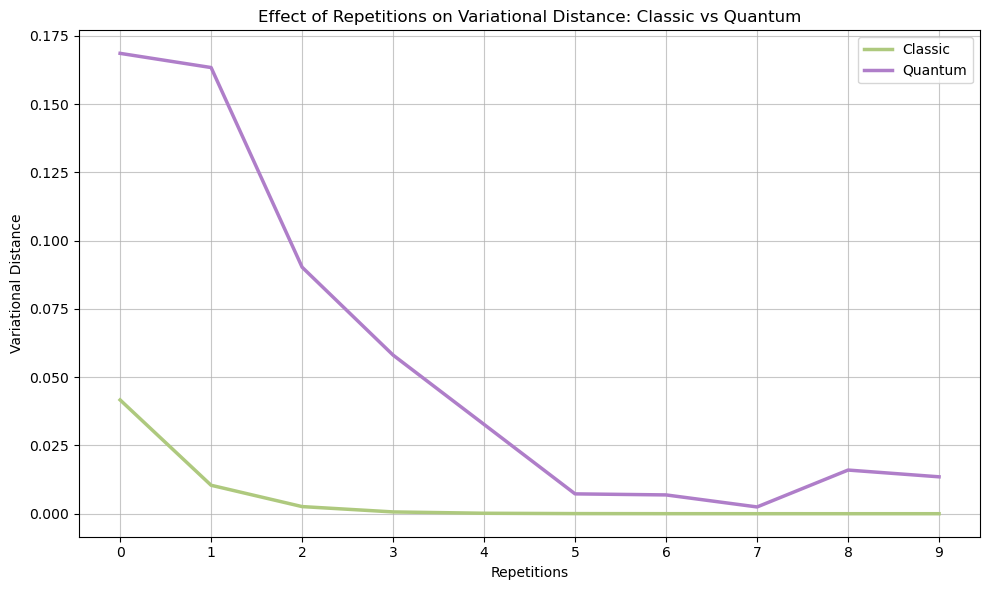

In [64]:
reps_vals = np.arange(10)
vd_vals_classic = []
vd_vals_quantum = []

for n in reps_vals:
    _, vd_classic = classic_evolution(n, P, pi)
    _, vd_quantum = quantum_evolution(n, W_qiskit, theta_list, phi_list, lambda_val, V_gate_dagger, V_gate, trials, pi)
    vd_vals_classic.append(vd_classic)
    vd_vals_quantum.append(vd_quantum)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(reps_vals, vd_vals_classic, color='#aec97e', label='Classic',linewidth=2.5)
plt.plot(reps_vals, vd_vals_quantum, color="#af7ec9", label='Quantum', linewidth=2.5)


plt.title('Effect of Repetitions on Variational Distance: Classic vs Quantum')
plt.xlabel('Repetitions')
plt.ylabel('Variational Distance')
plt.xticks(reps_vals)
plt.grid(True, alpha=0.7)
plt.legend(loc='best')

plt.tight_layout()
plt.show()